In [2]:
import zipfile
import os

zip_file = "archive (1).zip"

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("unemployment_data")

print("ZIP file extracted successfully!")
print("Files extracted:")
print(os.listdir("unemployment_data"))

ZIP file extracted successfully!
Files extracted:
['Unemployment_Rate_upto_11_2020.csv', 'Unemployment in India.csv']


In [3]:
import pandas as pd

df = pd.read_csv("unemployment_data/Unemployment in India.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

Dataset loaded successfully!
Shape of dataset: (768, 7)

First 5 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   

    Estimated Employed   Estimated Labour Participation Rate (%)   Area  
0           11999139.0                                     43.24  Rural  
1           11755881.0                                     42.05  Rural  
2           12086707.0                                     43.50  Rural  
3           12285693.0                                     43.97  Rural  
4           12256762.0                                     44.68  Rural  


In [4]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB

Missing Values:
Region                                      28
 Date                                       28
 Frequency                                  28
 Estimated Unemployment R

In [5]:
df = df.dropna()

print("Missing values removed.")
print("New shape of dataset:", df.shape)
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values removed.
New shape of dataset: (740, 7)

Missing values after cleaning:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Area                                        0
dtype: int64


In [6]:
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   
std                          10.721298        8.087988e+06   
min                           0.000000        4.942000e+04   
25%                           4.657500        1.190404e+06   
50%                           8.350000        4.744178e+06   
75%                          15.887500        1.127549e+07   
max                          76.740000        4.577751e+07   

       Estimated Labour Participation Rate (%)  
count                               740.000000  
mean                                 42.630122  
std                                   8.111094  
min                                  13.330000  
25%                                  38.062500  
50%                                  41.160000  
75%                                  45.505000  
max                         

In [8]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("Column names after cleaning:")
print(df.columns.tolist())

Column names after cleaning:
['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


In [9]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

print("Date column converted successfully.")
print(df['Date'].head())
print("\nDate data type:", df['Date'].dtype)

Date column converted successfully.
0   2019-05-31
1   2019-06-30
2   2019-07-31
3   2019-08-31
4   2019-09-30
Name: Date, dtype: datetime64[ns]

Date data type: datetime64[ns]


In [11]:
import matplotlib.pyplot as plt

print("Matplotlib imported successfully.")

Matplotlib imported successfully.


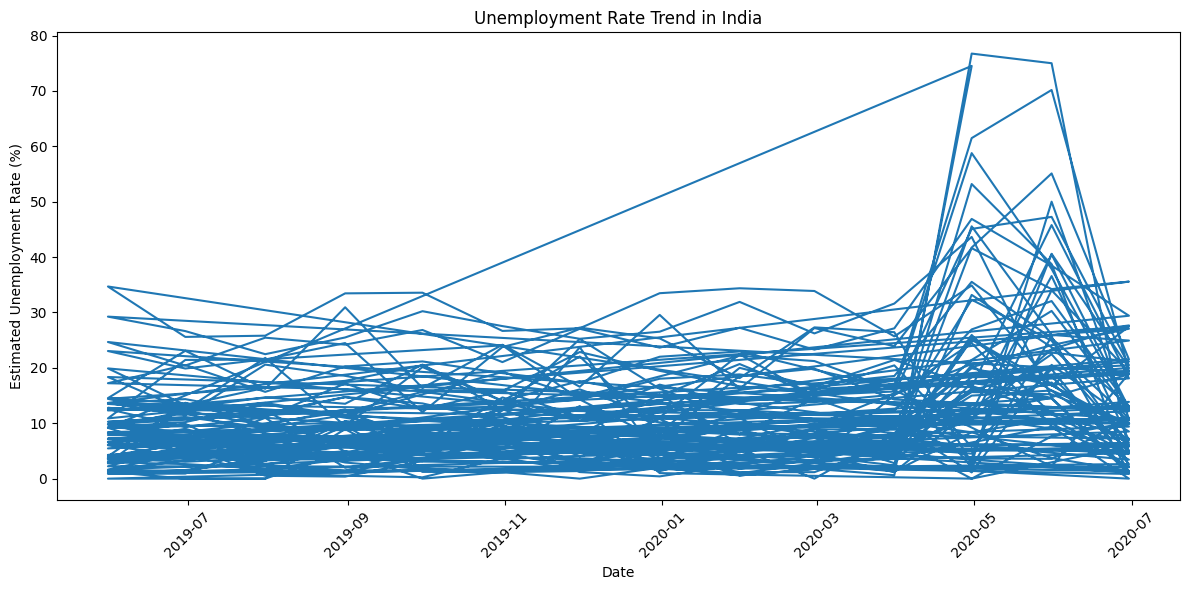

In [12]:
plt.figure(figsize=(12, 6))

plt.plot(
    df['Date'],
    df['Estimated Unemployment Rate (%)']
)

plt.title("Unemployment Rate Trend in India")
plt.xlabel("Date")
plt.ylabel("Estimated Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

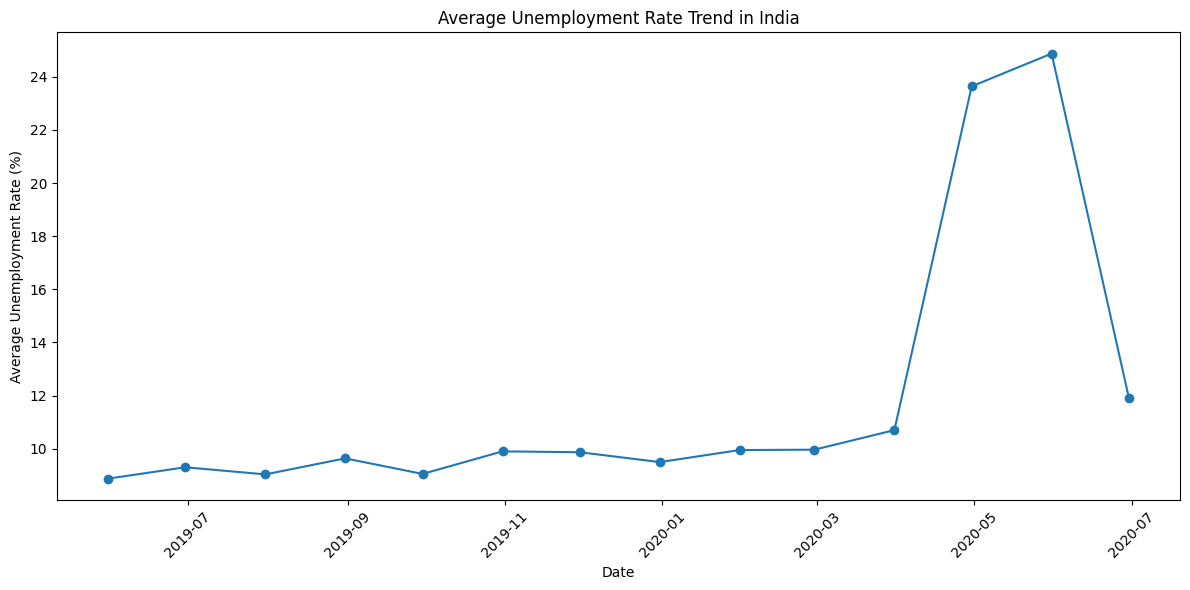

In [13]:
monthly_unemployment = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

plt.title("Average Unemployment Rate Trend in India")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
covid_data = df[df['Date'].dt.year == 2020]

print("Number of records in 2020:", len(covid_data))
print("\n2020 unemployment statistics:")
print(covid_data['Estimated Unemployment Rate (%)'].describe())

Number of records in 2020: 310

2020 unemployment statistics:
count    310.000000
mean      15.101581
std       13.550097
min        0.000000
25%        5.382500
50%       10.790000
75%       20.370000
max       76.740000
Name: Estimated Unemployment Rate (%), dtype: float64


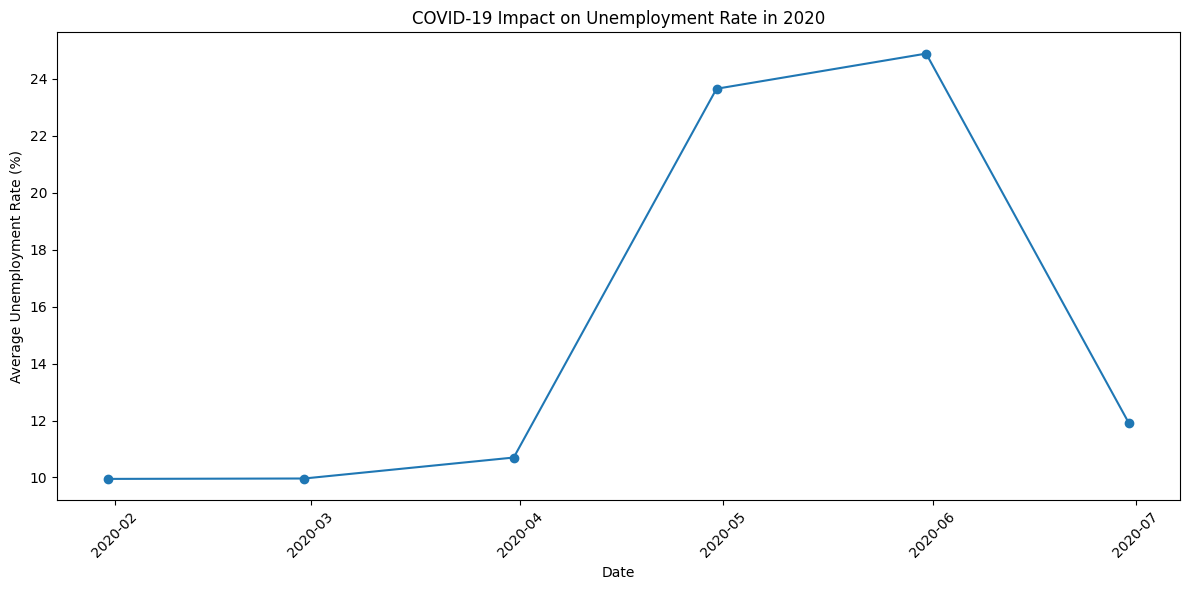

In [15]:
covid_monthly = covid_data.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12, 6))

plt.plot(
    covid_monthly.index,
    covid_monthly.values,
    marker='o'
)

plt.title("COVID-19 Impact on Unemployment Rate in 2020")
plt.xlabel("Date")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
state_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print("Average Unemployment Rate by Region:")
print(state_unemployment)

Average Unemployment Rate by Region:
Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Punjab              12.031071
Puducherry          10.215000
Kerala              10.123929
Tamil Nadu           9.284286
Goa                  9.274167
Chhattisgarh         9.240357
West Bengal          8.124643
Telangana            7.737857
Maharashtra          7.557500
Andhra Pradesh       7.477143
Madhya Pradesh       7.406429
Sikkim               7.249412
Karnataka            6.676071
Gujarat              6.663929
Uttarakhand          6.582963
Assam                6.428077
Odisha               5.657857
Meghalaya            4.798889
Name: Estimated Unemployment Rate (%), dtype: float64


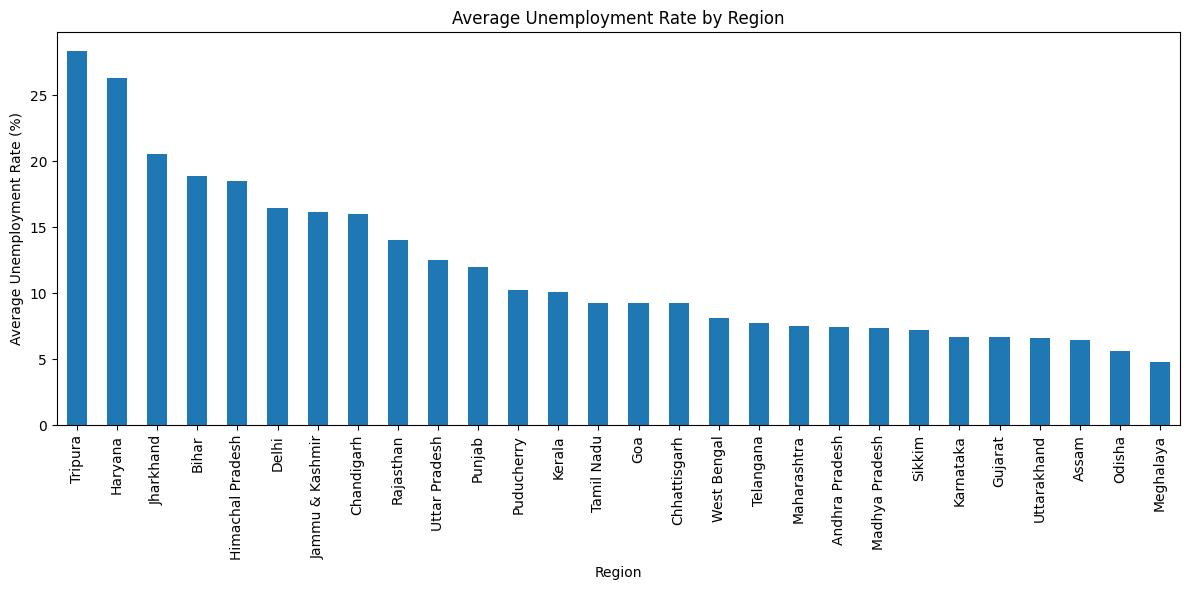

In [17]:
plt.figure(figsize=(12, 6))

state_unemployment.plot(kind='bar')

plt.title("Average Unemployment Rate by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [18]:
area_unemployment = (
    df.groupby('Area')['Estimated Unemployment Rate (%)']
    .mean()
    .sort_values(ascending=False)
)

print("Average Unemployment Rate by Area:")
print(area_unemployment)

Average Unemployment Rate by Area:
Area
Urban    13.166614
Rural    10.324791
Name: Estimated Unemployment Rate (%), dtype: float64


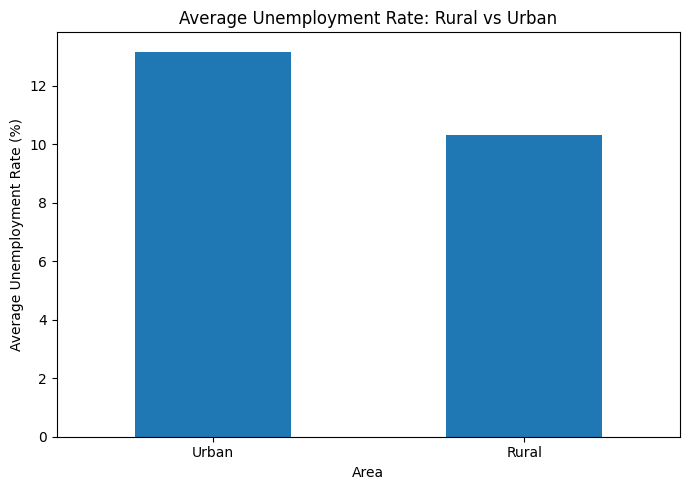

In [19]:
plt.figure(figsize=(7, 5))

area_unemployment.plot(kind='bar')

plt.title("Average Unemployment Rate: Rural vs Urban")
plt.xlabel("Area")
plt.ylabel("Average Unemployment Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [20]:
highest_region = state_unemployment.idxmax()
highest_rate = state_unemployment.max()

lowest_region = state_unemployment.idxmin()
lowest_rate = state_unemployment.min()

print("Highest average unemployment:")
print(highest_region, ":", round(highest_rate, 2), "%")

print("\nLowest average unemployment:")
print(lowest_region, ":", round(lowest_rate, 2), "%")

Highest average unemployment:
Tripura : 28.35 %

Lowest average unemployment:
Meghalaya : 4.8 %


In [21]:
df['Year'] = df['Date'].dt.year

yearly_unemployment = (
    df.groupby('Year')['Estimated Unemployment Rate (%)']
    .mean()
)

print("Average Unemployment Rate by Year:")
print(yearly_unemployment)

print("\nChange from 2019 to 2020:")

if 2019 in yearly_unemployment.index and 2020 in yearly_unemployment.index:
    change = yearly_unemployment.loc[2020] - yearly_unemployment.loc[2019]
    print("Change:", round(change, 2), "percentage points")
else:
    print("2019 or 2020 data is not available.")

Average Unemployment Rate by Year:
Year
2019     9.399047
2020    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64

Change from 2019 to 2020:
Change: 5.7 percentage points


In [22]:
highest_month = monthly_unemployment.idxmax()
highest_month_rate = monthly_unemployment.max()

print("Month with highest average unemployment:")
print(highest_month.strftime("%B %Y"))
print("Unemployment Rate:", round(highest_month_rate, 2), "%")

Month with highest average unemployment:
May 2020
Unemployment Rate: 24.88 %


In [23]:
lowest_month = monthly_unemployment.idxmin()
lowest_month_rate = monthly_unemployment.min()

print("Month with lowest average unemployment:")
print(lowest_month.strftime("%B %Y"))
print("Unemployment Rate:", round(lowest_month_rate, 2), "%")

Month with lowest average unemployment:
May 2019
Unemployment Rate: 8.87 %


In [24]:
rural_rate = area_unemployment.get('Rural')
urban_rate = area_unemployment.get('Urban')

print("Average Rural Unemployment Rate:", round(rural_rate, 2), "%")
print("Average Urban Unemployment Rate:", round(urban_rate, 2), "%")

difference = abs(rural_rate - urban_rate)

print("\nDifference between Rural and Urban:")
print(round(difference, 2), "percentage points")

if rural_rate > urban_rate:
    print("Rural unemployment was higher on average.")
else:
    print("Urban unemployment was higher on average.")

Average Rural Unemployment Rate: 10.32 %
Average Urban Unemployment Rate: 13.17 %

Difference between Rural and Urban:
2.84 percentage points
Urban unemployment was higher on average.


In [25]:
correlation = df[
    [
        'Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)'
    ]
].corr()

print("Correlation Matrix:")
print(correlation.round(2))

Correlation Matrix:
                                         Estimated Unemployment Rate (%)  \
Estimated Unemployment Rate (%)                                     1.00   
Estimated Employed                                                 -0.22   
Estimated Labour Participation Rate (%)                             0.00   

                                         Estimated Employed  \
Estimated Unemployment Rate (%)                       -0.22   
Estimated Employed                                     1.00   
Estimated Labour Participation Rate (%)                0.01   

                                         Estimated Labour Participation Rate (%)  
Estimated Unemployment Rate (%)                                             0.00  
Estimated Employed                                                          0.01  
Estimated Labour Participation Rate (%)                                     1.00  


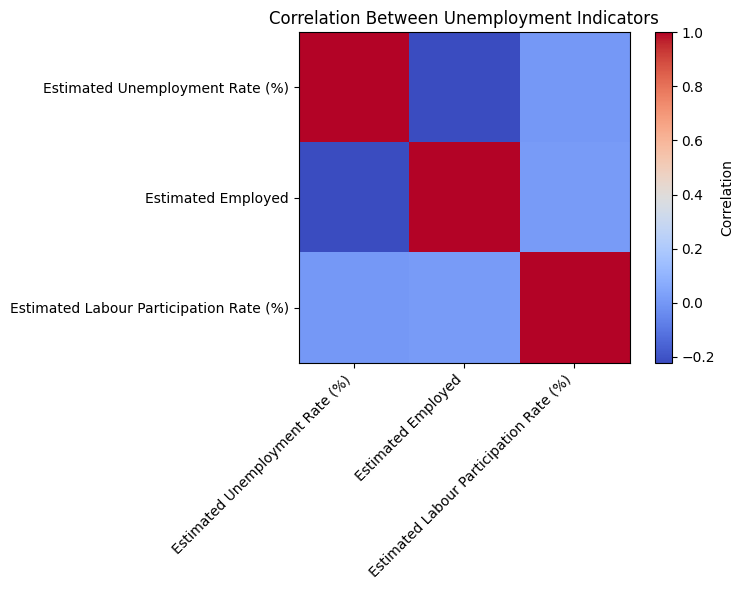

In [26]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation, cmap='coolwarm', interpolation='nearest')
plt.colorbar(label='Correlation')

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Between Unemployment Indicators")
plt.tight_layout()
plt.show()

In [27]:
overall_average = df['Estimated Unemployment Rate (%)'].mean()

print("Overall Average Unemployment Rate:")
print(round(overall_average, 2), "%")

Overall Average Unemployment Rate:
11.79 %


In [28]:
print("Dataset date range:")
print("Start Date:", df['Date'].min().strftime("%d %B %Y"))
print("End Date:", df['Date'].max().strftime("%d %B %Y"))

Dataset date range:
Start Date: 31 May 2019
End Date: 30 June 2020


In [29]:
number_of_regions = df['Region'].nunique()

print("Number of regions/states/UTs in the dataset:")
print(number_of_regions)

Number of regions/states/UTs in the dataset:
28


In [30]:
print("Number of records by Area:")
print(df['Area'].value_counts())

Number of records by Area:
Area
Urban    381
Rural    359
Name: count, dtype: int64


In [31]:
print("Frequency values in the dataset:")
print(df['Frequency'].value_counts())

Frequency values in the dataset:
Frequency
Monthly     381
 Monthly    359
Name: count, dtype: int64


In [32]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:")
print(duplicate_count)

Number of duplicate records:
0


In [33]:
print("Final cleaned dataset:")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Final cleaned dataset:
Number of rows: 740
Number of columns: 8


In [34]:
print("========== KEY FINDINGS ==========")

print("\n1. Overall Average Unemployment Rate:")
print(round(overall_average, 2), "%")

print("\n2. Highest Average Unemployment Region:")
print(highest_region, "-", round(highest_rate, 2), "%")

print("\n3. Lowest Average Unemployment Region:")
print(lowest_region, "-", round(lowest_rate, 2), "%")

print("\n4. Highest Unemployment Month:")
print(highest_month.strftime("%B %Y"), "-", round(highest_month_rate, 2), "%")

print("\n5. Lowest Unemployment Month:")
print(lowest_month.strftime("%B %Y"), "-", round(lowest_month_rate, 2), "%")

print("\n6. Rural vs Urban Difference:")
print(round(difference, 2), "percentage points")

print("\n7. Number of Regions:")
print(number_of_regions)

print("\n8. Dataset Date Range:")
print(
    df['Date'].min().strftime("%d %B %Y"),
    "to",
    df['Date'].max().strftime("%d %B %Y")
)

print("\n9. Final Dataset Size:")
print(df.shape[0], "rows x", df.shape[1], "columns")

========== KEY FINDINGS ==========

1. Overall Average Unemployment Rate:
11.79 %

2. Highest Average Unemployment Region:
Tripura - 28.35 %

3. Lowest Average Unemployment Region:
Meghalaya - 4.8 %

4. Highest Unemployment Month:
May 2020 - 24.88 %

5. Lowest Unemployment Month:
May 2019 - 8.87 %

6. Rural vs Urban Difference:
2.84 percentage points

7. Number of Regions:
28

8. Dataset Date Range:
31 May 2019 to 30 June 2020

9. Final Dataset Size:
740 rows x 8 columns


In [35]:
df.to_csv("Unemployment_India_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")
print("File name: Unemployment_India_Cleaned.csv")

Cleaned dataset saved successfully!
File name: Unemployment_India_Cleaned.csv


In [38]:
from google.colab import files

files.download("Unemployment_India_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Conclusion

The unemployment analysis was performed using Python by cleaning, exploring, and visualizing unemployment data from India. The analysis examined overall unemployment trends, regional differences, rural and urban unemployment, and changes during 2020.

The visualizations and statistical analysis helped identify periods of higher and lower unemployment and provided insights into differences between regions and areas. The analysis also highlighted the changes in unemployment during the COVID-19 period.

Overall, this project demonstrates how data analysis and visualization can be used to understand unemployment patterns and derive meaningful insights from real-world data.